# Data reading

In [1]:
import pandas as pd

df = pd.read_csv("movies_dataset.csv")
df.head()

,id,title,rating,year,genres,overview,cast,director,poster_url,poster_local
0,5,Four Rooms,5.898,1995,Comedy,It's Ted the Bellhop's first night on the job....,Tim Roth | Jennifer Beals | David Proval | Ion...,Allison Anders | Alexandre Rockwell | Quentin ...,https://image.tmdb.org/t/p/w500/75aHn1NOYXh4M7...,posters\90c62e0d671882e3b4a8070109a9b9b1.jpg
1,11,Star Wars,8.203,1977,"Adventure, Action, Science Fiction",Princess Leia is captured and held hostage by ...,Mark Hamill | Harrison Ford | Carrie Fisher | ...,George Lucas,https://image.tmdb.org/t/p/w500/6FfCtAuVAW8XJj...,posters\0dd0e70356dd519fd0dfcc9780e11f54.jpg
2,12,Finding Nemo,7.818,2003,"Animation, Family, Adventure","Nemo, an adventurous young clownfish, is unexp...",Albert Brooks | Ellen DeGeneres | Alexander Go...,Andrew Stanton,https://image.tmdb.org/t/p/w500/eHuGQ10FUzK1md...,posters\e3671f40bac65417c5d9d63741f366b5.jpg
3,13,Forrest Gump,8.464,1994,"Comedy, Drama, Romance",A man with a low IQ has accomplished great thi...,Tom Hanks | Robin Wright | Gary Sinise | Sally...,Robert Zemeckis,https://image.tmdb.org/t/p/w500/Cw4hIUIAmSYfK9...,posters\4ad431c478cc8213fe514b1b8e9e41f3.jpg
4,14,American Beauty,8.000,1999,Drama,"Lester Burnham, a depressed suburban father in...",Kevin Spacey | Annette Bening | Thora Birch | ...,Sam Mendes,https://image.tmdb.org/t/p/w500/wby9315QzVKdW9...,posters\985897d826bd9901207284642155587f.jpg


# Data check

DATA SHAPE
(6000, 10)

FIRST 5 ROWS
   id            title  rating  year                              genres  \
0   5       Four Rooms   5.898  1995                              Comedy   
1  11        Star Wars   8.203  1977  Adventure, Action, Science Fiction   
2  12     Finding Nemo   7.818  2003        Animation, Family, Adventure   
3  13     Forrest Gump   8.464  1994              Comedy, Drama, Romance   
4  14  American Beauty   8.000  1999                               Drama   

                                            overview  \
0  It's Ted the Bellhop's first night on the job....   
1  Princess Leia is captured and held hostage by ...   
2  Nemo, an adventurous young clownfish, is unexp...   
3  A man with a low IQ has accomplished great thi...   
4  Lester Burnham, a depressed suburban father in...   

                                                cast  \
0  Tim Roth | Jennifer Beals | David Proval | Ion...   
1  Mark Hamill | Harrison Ford | Carrie Fisher | ...   
2 

C:\Users\zizo\AppData\Local\Temp\ipykernel_23568\1360137585.py:106: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = df.select_dtypes(include=['object']).columns


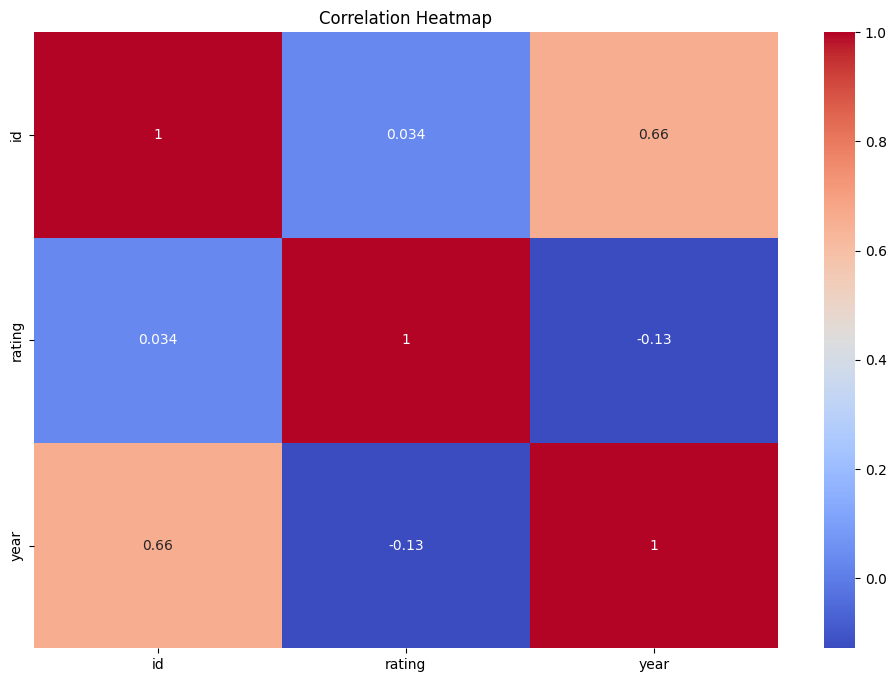

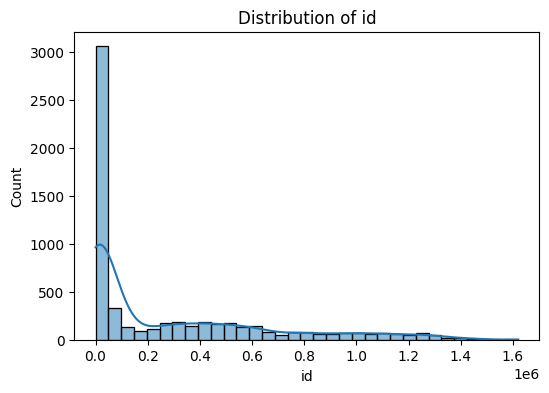

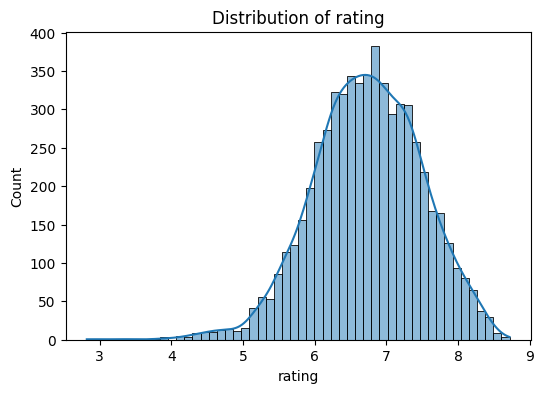

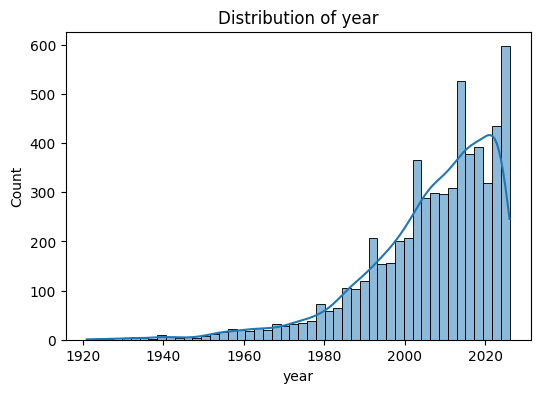

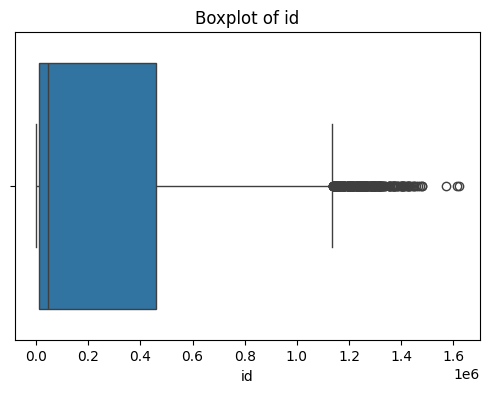

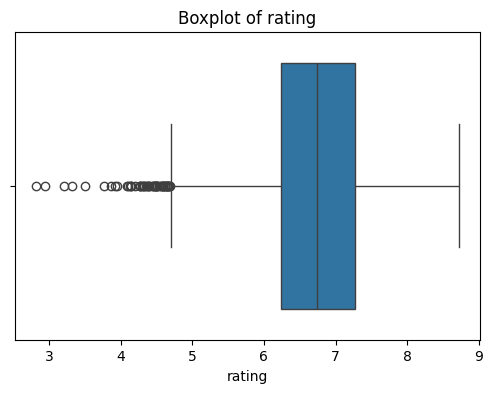

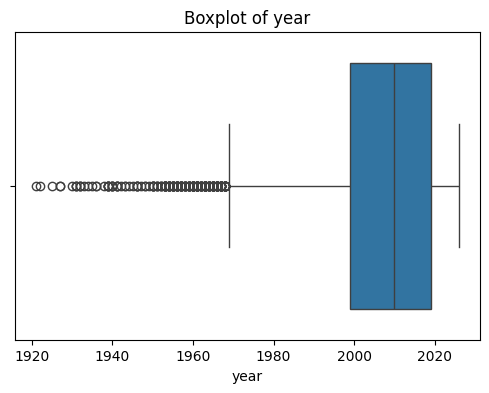


FINAL DATA PROBLEMS SUMMARY

1. Dataset Shape: (6000, 10)

2. Missing Values:
cast        2
director    1
dtype: int64

3. Duplicate Rows:
0

4. Numerical Columns:
['id', 'rating', 'year']

5. Categorical Columns:
['title', 'genres', 'overview', 'cast', 'director', 'poster_url', 'poster_local']



In [2]:
# =========================================
# DATA UNDERSTANDING & DATA CHECKING
# =========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# =========================================
# 1. BASIC INFO
# =========================================

print("="*50)
print("DATA SHAPE")
print("="*50)
print(df.shape)

print("\n" + "="*50)
print("FIRST 5 ROWS")
print("="*50)
print(df.head())

print("\n" + "="*50)
print("LAST 5 ROWS")
print("="*50)
print(df.tail())

# =========================================
# 2. COLUMN INFO
# =========================================

print("\n" + "="*50)
print("COLUMN NAMES")
print("="*50)
print(df.columns)

print("\n" + "="*50)
print("DATA TYPES")
print("="*50)
print(df.dtypes)

print("\n" + "="*50)
print("FULL INFO")
print("="*50)
print(df.info())

# =========================================
# 3. MISSING VALUES
# =========================================

print("\n" + "="*50)
print("MISSING VALUES")
print("="*50)

missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percent
})

print(missing_table)

# =========================================
# 4. DUPLICATES
# =========================================

print("\n" + "="*50)
print("DUPLICATED ROWS")
print("="*50)

duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

# =========================================
# 5. UNIQUE VALUES
# =========================================

print("\n" + "="*50)
print("UNIQUE VALUES IN EACH COLUMN")
print("="*50)

for col in df.columns:
    print(f"\nColumn: {col}")
    print("Unique Values Count:", df[col].nunique())
    print(df[col].unique()[:10])  # أول 10 قيم فقط

# =========================================
# 6. STATISTICS
# =========================================

print("\n" + "="*50)
print("NUMERICAL STATISTICS")
print("="*50)

print(df.describe())

# =========================================
# 7. CATEGORICAL COLUMNS
# =========================================

cat_cols = df.select_dtypes(include=['object']).columns

print("\n" + "="*50)
print("CATEGORICAL COLUMNS")
print("="*50)

for col in cat_cols:
    print(f"\nColumn: {col}")
    print(df[col].value_counts())
    print("-"*30)

# =========================================
# 8. CHECK OUTLIERS
# =========================================

num_cols = df.select_dtypes(include=np.number).columns

print("\n" + "="*50)
print("OUTLIERS CHECK")
print("="*50)

for col in num_cols:
    
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    
    outliers = df[(df[col] < lower) | (df[col] > upper)]
    
    print(f"{col}: {len(outliers)} outliers")

# =========================================
# 9. CORRELATION
# =========================================

plt.figure(figsize=(12,8))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")
plt.show()

# =========================================
# 10. DISTRIBUTION
# =========================================

for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.histplot(df[col], kde=True)
    
    plt.title(f"Distribution of {col}")
    
    plt.show()

# =========================================
# 11. BOXPLOT FOR OUTLIERS
# =========================================

for col in num_cols:
    
    plt.figure(figsize=(6,4))
    
    sns.boxplot(x=df[col])
    
    plt.title(f"Boxplot of {col}")
    
    plt.show()

# =========================================
# 12. FINAL SUMMARY
# =========================================

print("\n" + "="*50)
print("FINAL DATA PROBLEMS SUMMARY")
print("="*50)

print(f"""
1. Dataset Shape: {df.shape}

2. Missing Values:
{missing[missing > 0]}

3. Duplicate Rows:
{duplicates}

4. Numerical Columns:
{list(num_cols)}

5. Categorical Columns:
{list(cat_cols)}
""")

In [3]:
from collections import Counter

# ============================================
# COUNT EACH INDIVIDUAL GENRE
# ============================================

all_genres = []

for genres in df['genres'].dropna():

    split_genres = genres.split(',')

    split_genres = [g.strip() for g in split_genres]

    all_genres.extend(split_genres)

genre_counter = Counter(all_genres)

print(genre_counter)

Counter({'Drama': 2402, 'Action': 1941, 'Comedy': 1873, 'Thriller': 1732, 'Adventure': 1332, 'Crime': 1003, 'Romance': 935, 'Science Fiction': 896, 'Fantasy': 850, 'Horror': 829, 'Family': 759, 'Animation': 715, 'Mystery': 561, 'History': 292, 'War': 193, 'Music': 138, 'Western': 108, 'TV Movie': 56, 'Documentary': 31})


In [4]:
from collections import Counter
import pandas as pd

# ==========================================
# SPLIT GENRES
# ==========================================

all_genres = []

for genres in df['genres']:

    split_genres = genres.lower().split(',')

    split_genres = [g.strip() for g in split_genres]

    all_genres.extend(split_genres)

# ==========================================
# COUNT GENRES
# ==========================================

genre_counter = Counter(all_genres)

print(genre_counter)

# ==========================================
# KEEP ONLY COMMON GENRES
# ==========================================

threshold = 50

common_genres = {
    genre for genre, count in genre_counter.items()
    if count >= threshold
}

print("\nCommon Genres:")
print(common_genres)

# ==========================================
# CLEAN GENRES COLUMN
# ==========================================

def clean_genres(genres):

    split_genres = genres.lower().split(',')

    split_genres = [g.strip() for g in split_genres]

    # الاحتفاظ بالمشهور فقط
    filtered = [
        g for g in split_genres
        if g in common_genres
    ]

    return ', '.join(filtered)

df['genres'] = df['genres'].apply(clean_genres)

# ==========================================
# REMOVE EMPTY ROWS
# ==========================================

df = df[df['genres'] != '']

# ==========================================
# FINAL CHECK
# ==========================================

print("\nFinal Shape:", df.shape)

print("\nUnique Genres:")
print(df['genres'].nunique())

Counter({'drama': 2402, 'action': 1941, 'comedy': 1873, 'thriller': 1732, 'adventure': 1332, 'crime': 1003, 'romance': 935, 'science fiction': 896, 'fantasy': 850, 'horror': 829, 'family': 759, 'animation': 715, 'mystery': 561, 'history': 292, 'war': 193, 'music': 138, 'western': 108, 'tv movie': 56, 'documentary': 31})

Common Genres:
{'tv movie', 'history', 'science fiction', 'animation', 'drama', 'action', 'romance', 'mystery', 'music', 'crime', 'horror', 'fantasy', 'family', 'war', 'thriller', 'western', 'adventure', 'comedy'}

Final Shape: (5985, 10)

Unique Genres:
1672


In [5]:
import os

# ==========================================
# CREATE NEW FOLDER
# ==========================================

folder_name = "cleaned_data"

os.makedirs(folder_name, exist_ok=True)

# ==========================================
# SAVE CLEANED DATA
# ==========================================

save_path = os.path.join(folder_name, "movies_cleaned.csv")

df.to_csv(save_path, index=False)

print("Cleaned data saved successfully ✅")
print("Location:", save_path)

Cleaned data saved successfully ✅
Location: cleaned_data\movies_cleaned.csv


# Data preprocessing

In [6]:
# =========================================================
# COMPLETE DATA CLEANING & PREPROCESSING
# =========================================================

import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# =========================================================
# 1. REMOVE USELESS COLUMNS
# =========================================================

useless_cols = ['id', 'poster_url', 'poster_local']

for col in useless_cols:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)

print("\nDropped useless columns.")

# =========================================================
# 2. HANDLE MISSING VALUES
# =========================================================

# Text columns
text_cols = ['cast', 'director', 'overview', 'genres', 'title']

for col in text_cols:
    if col in df.columns:
        df[col] = df[col].fillna("Unknown")

# Numerical columns
num_cols = df.select_dtypes(include=np.number).columns

for col in num_cols:
    df[col] = df[col].fillna(df[col].median())

print("\nMissing values handled.")

# =========================================================
# 3. REMOVE DUPLICATES
# =========================================================

before = df.shape[0]

df.drop_duplicates(inplace=True)

after = df.shape[0]

print(f"\nRemoved {before-after} duplicate rows.")

# =========================================================
# 4. HANDLE OUTLIERS (IQR METHOD)
# =========================================================

numerical_cols = ['rating', 'year']

for col in numerical_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    # بدل ما نحذفهم نعمل clipping
    df[col] = np.clip(df[col], lower, upper)

print("\nOutliers handled.")

# =========================================================
# 5. FIX SKEWED DISTRIBUTION
# =========================================================

# لو التوزيع معوج نستخدم log transform

if 'year' in df.columns:
    df['year'] = np.log1p(df['year'])

print("\nSkewness fixed.")

# =========================================================
# 6. CLEAN TEXT
# =========================================================

import re

def clean_text(text):

    text = text.lower()

    text = re.sub(r"[^a-zA-Z0-9 ]", "", text)

    text = re.sub(r"\s+", " ", text)

    return text.strip()

text_features = ['title', 'genres', 'overview', 'cast', 'director']

for col in text_features:

    if col in df.columns:

        df[col] = df[col].astype(str).apply(clean_text)

print("\nText cleaned.")

# =========================================================
# 7. COMBINE TEXT FEATURES
# =========================================================

df['combined_text'] = (
    df['title'] + " " +
    df['genres'] + " " +
    df['overview'] + " " +
    df['cast'] + " " +
    df['director']
)

print("\nText features combined.")

# =========================================================
# 8. TF-IDF VECTORIZATION
# =========================================================

tfidf = TfidfVectorizer(
    max_features=5000,
    stop_words='english'
)

X_text = tfidf.fit_transform(df['combined_text']).toarray()

print("\nTF-IDF applied.")
print("Text feature shape:", X_text.shape)

# =========================================================
# 9. NUMERICAL FEATURES
# =========================================================

X_num = df[['rating', 'year']].values

# Scaling
scaler = StandardScaler()

X_num = scaler.fit_transform(X_num)

print("\nNumerical features scaled.")

# =========================================================
# 10. COMBINE ALL FEATURES
# =========================================================

X = np.concatenate([X_text, X_num], axis=1)

print("\nFinal feature shape:", X.shape)

# =========================================================
# 11. TARGET COLUMN
# =========================================================

# غير target حسب مشروعك
# مثال:
# y = df['target']

# مؤقتًا:
y = df['rating']

# =========================================================
# 12. TRAIN TEST SPLIT
# =========================================================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("\nTrain/Test split done.")

# =========================================================
# FINAL CHECK
# =========================================================

print("\n" + "="*50)
print("FINAL CLEANED DATA")
print("="*50)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)

print("\nNo Missing Values:")
print(df.isnull().sum().sum())

print("\nSample Data:")
print(df.head())

print("\nDATA IS READY FOR NEURAL NETWORK ✅")


Dropped useless columns.

Missing values handled.

Removed 0 duplicate rows.

Outliers handled.

Skewness fixed.

Text cleaned.

Text features combined.

TF-IDF applied.
Text feature shape: (5985, 5000)

Numerical features scaled.

Final feature shape: (5985, 5002)

Train/Test split done.

FINAL CLEANED DATA
X_train shape: (4788, 5002)
X_test shape : (1197, 5002)

No Missing Values:
0

Sample Data:
             title  rating      year                            genres  \
0       four rooms   5.898  7.598900                            comedy   
1        star wars   8.203  7.589842  adventure action science fiction   
2     finding nemo   7.818  7.602900        animation family adventure   
3     forrest gump   8.464  7.598399              comedy drama romance   
4  american beauty   8.000  7.600902                             drama   

                                            overview  \
0  its ted the bellhops first night on the joband...   
1  princess leia is captured and held ho

In [7]:
import os
import shutil
import pandas as pd
from PIL import Image
from collections import Counter
import random

# ==========================================
# LOAD DATA
# ==========================================

df = pd.read_csv("movies_dataset.csv")

# ==========================================
# PATHS
# ==========================================

SOURCE_FOLDER = "posters"
OUTPUT_FOLDER = "clean_dataset"

os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ==========================================
# TAKE PRIMARY GENRE ONLY
# ==========================================

df['main_genre'] = df['genres'].apply(
    lambda x: x.split(',')[0].strip().lower()
)

# ==========================================
# REMOVE RARE GENRES
# ==========================================

genre_counts = df['main_genre'].value_counts()

MIN_IMAGES = 50

valid_genres = genre_counts[
    genre_counts >= MIN_IMAGES
].index

df = df[df['main_genre'].isin(valid_genres)]

print("Genres kept:")
print(df['main_genre'].value_counts())

# ==========================================
# BALANCE DATASET
# ==========================================

MAX_IMAGES = 300

balanced_df = []

for genre in valid_genres:

    genre_df = df[df['main_genre'] == genre]

    # تقليل الجينرز الكبيرة
    if len(genre_df) > MAX_IMAGES:

        genre_df = genre_df.sample(
            MAX_IMAGES,
            random_state=42
        )

    balanced_df.append(genre_df)

df = pd.concat(balanced_df)

print("\nBalanced Dataset:")
print(df['main_genre'].value_counts())

# ==========================================
# CREATE GENRE FOLDERS
# ==========================================

for genre in df['main_genre'].unique():

    genre_folder = os.path.join(
        OUTPUT_FOLDER,
        genre
    )

    os.makedirs(genre_folder, exist_ok=True)

# ==========================================
# COPY CLEAN IMAGES
# ==========================================

bad_images = 0
saved_images = 0

for index, row in df.iterrows():

    try:

        img_name = row['poster_local']

        # لو poster_local فيه path كامل
        img_path = img_name

        # لو اسم الصورة فقط
        if not os.path.exists(img_path):

            img_path = os.path.join(
                SOURCE_FOLDER,
                img_name
            )

        # ==================================
        # CHECK IMAGE
        # ==================================

        img = Image.open(img_path)

        img.verify()

        # إعادة فتح الصورة
        img = Image.open(img_path)

        # ==================================
        # RESIZE
        # ==================================

        img = img.resize((224, 224))

        # ==================================
        # SAVE
        # ==================================

        genre = row['main_genre']

        save_path = os.path.join(
            OUTPUT_FOLDER,
            genre,
            os.path.basename(img_path)
        )

        img.save(save_path)

        saved_images += 1

    except:

        bad_images += 1

        continue

# ==========================================
# FINAL REPORT
# ==========================================

print("\n" + "="*50)

print("DONE ✅")

print("="*50)

print("Saved Images:", saved_images)

print("Bad Images Removed:", bad_images)

print("\nFinal Genres:")

print(df['main_genre'].value_counts())

Genres kept:
main_genre
action             1102
drama              1068
comedy              864
horror              528
animation           452
adventure           392
thriller            301
crime               261
science fiction     229
romance             178
fantasy             173
family              170
mystery              75
western              53
Name: count, dtype: int64

Balanced Dataset:
main_genre
action             300
drama              300
comedy             300
horror             300
animation          300
adventure          300
thriller           300
crime              261
science fiction    229
romance            178
fantasy            173
family             170
mystery             75
western             53
Name: count, dtype: int64

DONE ✅
Saved Images: 3239
Bad Images Removed: 0

Final Genres:
main_genre
action             300
drama              300
comedy             300
horror             300
animation          300
adventure          300
thriller           300


In [8]:
import os

print(os.listdir())

['a7a', 'cleaned', 'cleaned.zip', 'cleaned_data', 'clean_dataset', 'Cosine Similarity Model train.ipynb', 'data preprocessing.ipynb', 'movies_dataset.csv', 'posters', 'web scraby.ipynb']


# TF-IDF